In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [60]:
def compute_cumulative_outcome_fractions(df, masses, N):
    """
    df      : DataFrame with columns ['mass', 'time', 'particle_id', 'result']
              where result is 'Ejected' or 'Captured', and each row represents
              the time at which that particle's outcome occurred
    masses  : list/array of unique mass values, in the same order as N
    N       : list/array of total particle counts, one per mass in `masses`

    Returns
    -------
    ejection_df, capture_df : DataFrames indexed by mass, columns = sorted
                               unique time values, entries = CUMULATIVE
                               fraction of N with that result by that time
                               (i.e. fraction ejected/captured at or before
                               each time, monotonically non-decreasing
                               across each row)
    """
    if len(masses) != len(N):
        raise ValueError("masses and N must be the same length")

    mass_to_N = dict(zip(masses, N))

    times = np.sort(df["time"].unique())

    ejection_df = pd.DataFrame(index=masses, columns=times, dtype=float)
    capture_df = pd.DataFrame(index=masses, columns=times, dtype=float)

    for mass in masses:
        mass_df = df[df["mass"] == mass]
        denom = mass_to_N[mass]

        counts = (
            mass_df.groupby(["time", "result"])
            .size()
            .unstack(fill_value=0)
        )

        # reindex to the full sorted time axis, filling any missing times
        # with 0 new outcomes at that time, then cumsum across time
        ejected_counts = counts.get("Ejected", pd.Series(0, index=counts.index))
        captured_counts = counts.get("Captured", pd.Series(0, index=counts.index))

        ejected_counts = ejected_counts.reindex(times, fill_value=0)
        captured_counts = captured_counts.reindex(times, fill_value=0)

        ejection_df.loc[mass] = (ejected_counts.cumsum() / denom).values
        capture_df.loc[mass] = (captured_counts.cumsum() / denom).values

    return ejection_df, capture_df

In [104]:
df=pd.read_csv('/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/local_20260914_185317_ejection_results.txt', header=None)

In [105]:
df.columns=['mass','time','result']

In [106]:
ejection_df, capture_df=compute_cumulative_outcome_fractions(df, df.mass.unique(),[800,800,800,800,800,800])

In [107]:
ejection_df

,0.000000e+00,9.993711e+02,1.990074e+03,1.995007e+03,2.985112e+03,4.998423e+03,7.980028e+03,8.955335e+03,8.988718e+03,1.097254e+04,...,1.958690e+06,1.993685e+06,2.012682e+06,2.052675e+06,2.088670e+06,2.120665e+06,2.226648e+06,2.231647e+06,2.236646e+06,2.283639e+06
0.010000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.78375,0.78375,0.78375,0.78375,0.78375,0.78375,0.78375,0.78375,0.78375,0.78375
0.005012,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.74875,0.74875,0.74875,0.74875,0.74875,0.74875,0.74875,0.74875,0.74875,0.74875
0.002512,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.74750,0.74750,0.74750,0.74750,0.74750,0.74750,0.74750,0.74750,0.74750,0.74750
0.001259,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.71500,0.71500,0.71500,0.71500,0.71500,0.71500,0.71500,0.71500,0.71500,0.71500
0.000631,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.69875,0.69875,0.69875,0.69875,0.69875,0.69875,0.69875,0.69875,0.69875,0.69875
0.000316,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.70875,0.71000,0.71125,0.71250,0.71375,0.71500,0.71625,0.71750,0.71875,0.72000


In [108]:
files=[
    '/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/remaining_particles_local_20260914_185317_5.csv',
    '/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/remaining_particles_local_20260914_185317_5.csv',
    '/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/remaining_particles_local_20260914_185317_5.csv',
    '/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/remaining_particles_local_20260914_185317_5.csv',
    '/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/remaining_particles_local_20260914_185317_5.csv',
    '/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/remaining_particles_local_20260914_185317_5.csv',


    


]

In [109]:
df=pd.DataFrame()
for file in files:
    temp_df=pd.read_csv(file)
    df=pd.concat([df,temp_df], ignore_index=True)

In [110]:
left_counts = ejection_df[ejection_df.columns[-1]]*800

unbound_counts = (
    df.groupby("m_planet")["a"]
    .apply(lambda x: (x == "Unbound").sum())
)


total_affected = left_counts.add(unbound_counts, fill_value=0)

In [114]:
unbound_counts

m_planet
0.000316    12
Name: a, dtype: int64

In [111]:
total_affected

0.000316    588.0
0.000631    559.0
0.001259    572.0
0.002512    598.0
0.005012    599.0
0.010000    627.0
dtype: float64

(0.6, 0.85)

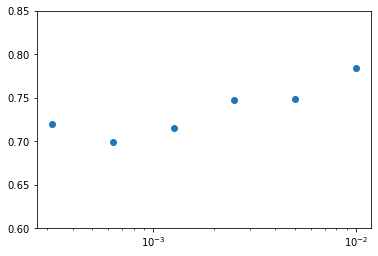

In [113]:
plt.scatter(ejection_df.index, ejection_df[ejection_df.columns[-1]])
#plt.scatter(total_affected.index,total_affected/800)
plt.xscale('log')
plt.ylim(0.6,0.85)